Here, we see how our loss changes as a function of the various hyperparameters we were interested in:

In [38]:
import os

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
seed = 888

data_path = '/Users/hratchbaghdassarian/Downloads/sclembas_data'#'/nobackup/users/hmbaghda/scLEMBAS/analysis'


In [6]:
val_res = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_k_fold_validation_results.csv'), index_col = 0)

In [37]:
avg_loss = val_res.groupby(['max_epochs', 'max_lr', 'train_batch_size'])['emd_loss_total'].mean()
min_loss = avg_loss.min()
best_params = avg_loss[avg_loss == min_loss]

print('The best hyperparameters are: {:.0f} epochs, {:.4f} learning rate, and a train batch size of {:.0f}'.format(best_params.index[0][0], 
                                                                                                          best_params.index[0][1], 
                                                                                                          best_params.index[0][2]))

The best hyperparameters are: 300 epochs, 0.0010 learning rate, and a train batch size of 2048


''

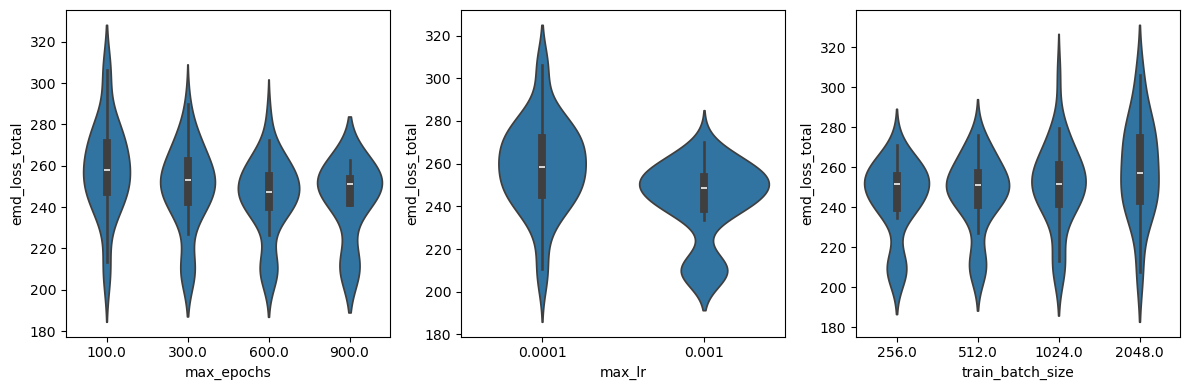

In [48]:
fig, ax = plt.subplots(figsize = (12, 4), ncols = 3)

sns.violinplot(data = val_res, x = 'max_epochs', y = 'emd_loss_total', ax = ax[0])
sns.violinplot(data = val_res, x = 'max_lr', y = 'emd_loss_total', ax = ax[1])
sns.violinplot(data = val_res, x = 'train_batch_size', y = 'emd_loss_total', ax = ax[2])
fig.tight_layout()
;

/Users/hratchbaghdassarian/miniforge3/envs/scLEMBAS/lib/python3.12/site-packages/pandas/core/series.py:1031: RuntimeWarning: invalid value encountered in cast
  arr = np.asarray(values, dtype=dtype)


<Axes: xlabel='max_epochs', ylabel='max_lr'>

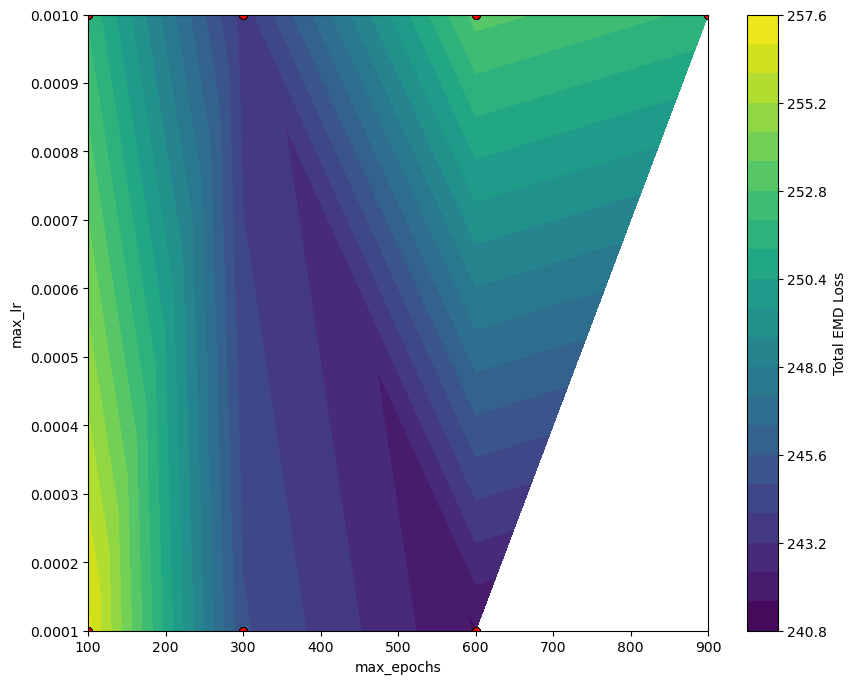

In [57]:
plt.figure(figsize=(10, 8))
x = val_res.max_epochs
y = val_res.max_lr
z = val_res.emd_loss_total

contour = plt.tricontourf(x, y, z, levels=20, cmap="viridis")
plt.colorbar(contour, label="Total EMD Loss")

# Add scatter plot of the points for reference
sns.scatterplot(x=x, y=y, color='red', s=30, edgecolor='black')
